# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:
   Dataset diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset: **Pima Indians Diabetes Database**

Dataset ini berisi data medis pasien perempuan keturunan Indian Pima untuk memprediksi apakah pasien menderita diabetes atau tidak. Terdapat 8 fitur medis dan 1 target kolom 'Outcome'.

**Fitur-fitur:**
1. Pregnancies - Jumlah kehamilan
2. Glucose - Kadar glukosa plasma (mg/dL)
3. BloodPressure - Tekanan darah diastolik (mm Hg)
4. SkinThickness - Ketebalan lipatan kulit trisep (mm)
5. Insulin - Kadar insulin serum (mu U/mL)
6. BMI - Index massa tubuh (weight in kg/(height in m)^2)
7. DiabetesPedigreeFunction - Fungsi keturunan diabetes
8. Age - Usia (tahun)
9. Outcome - Target (0 = Tidak Diabetes, 1 = Diabetes)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport')

Semua library berhasil diimport


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya.

In [3]:
df = pd.read_csv('/content/diabetes_raw/diabetes.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# **4. Exploratory Data Analysis (EDA)**

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# Cek missing values
print('Missing values per kolom:')
print(df.isnull().sum())

# Cek duplikasi
print(f'\nJumlah duplikasi: {df.duplicated().sum()}')

Missing values per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah duplikasi: 0


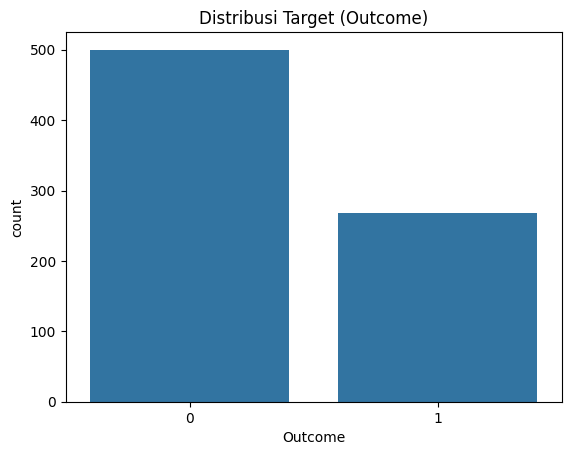

Outcome
0    500
1    268
Name: count, dtype: int64
Persentase: 
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [7]:
# Distribusi target
sns.countplot(data=df, x='Outcome')
plt.title('Distribusi Target (Outcome)')
plt.show()
print(df['Outcome'].value_counts())
print(f"Persentase: \n{df['Outcome'].value_counts(normalize=True) * 100}")

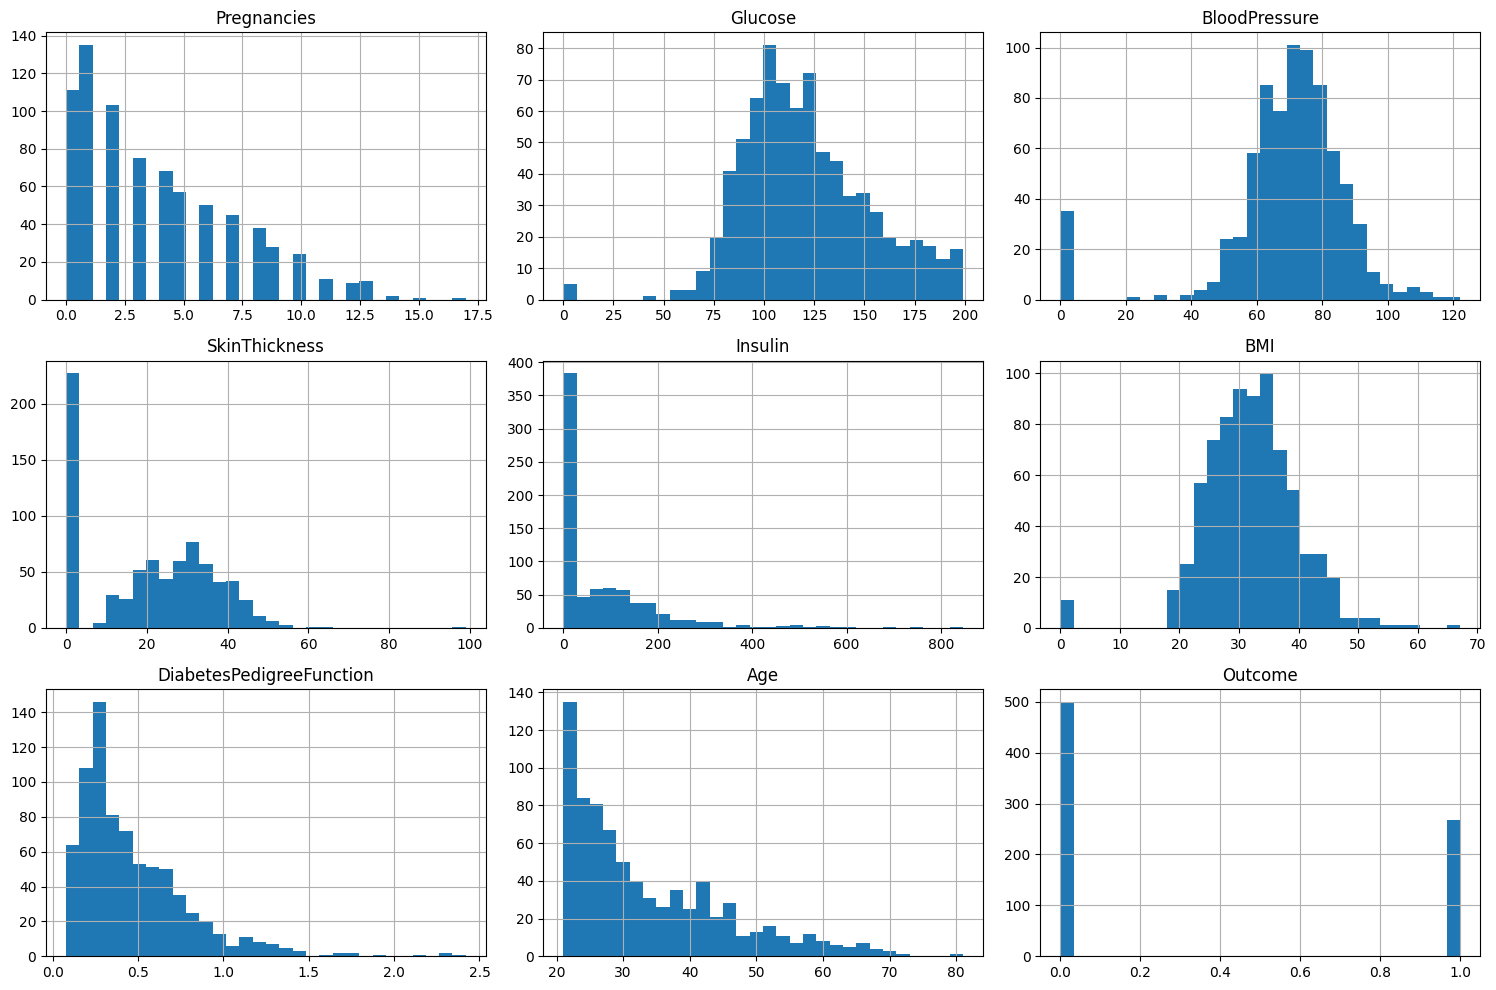

In [8]:
# Distribusi fitur numerik
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

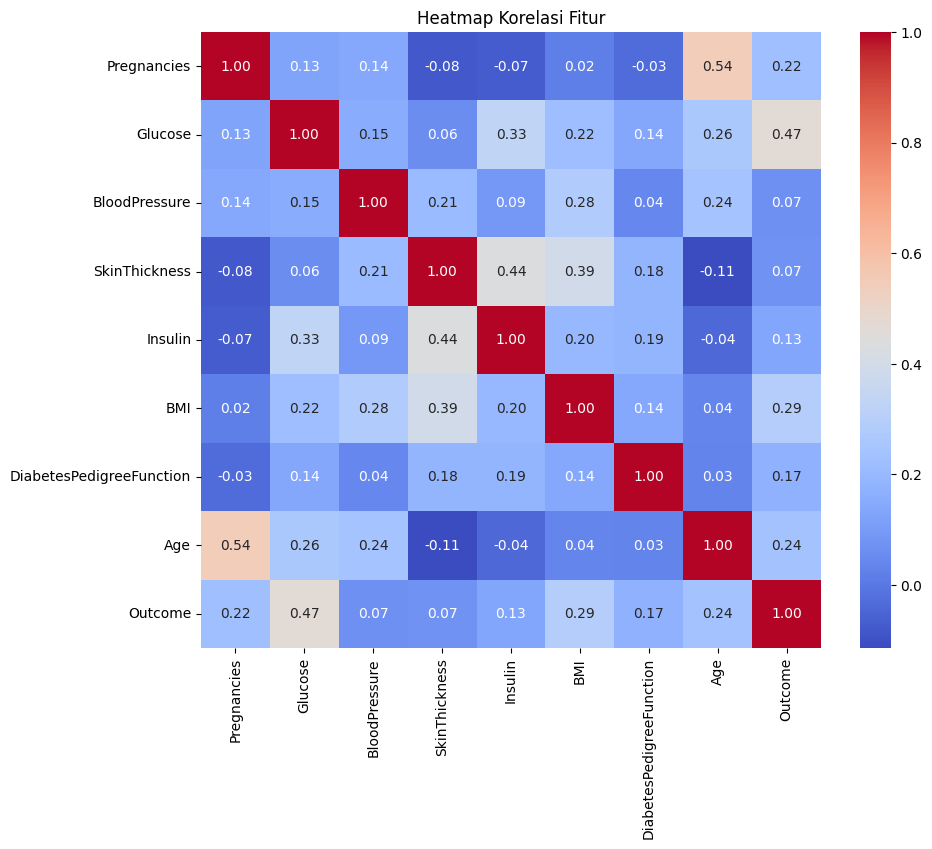

In [9]:
# Heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur')
plt.show()

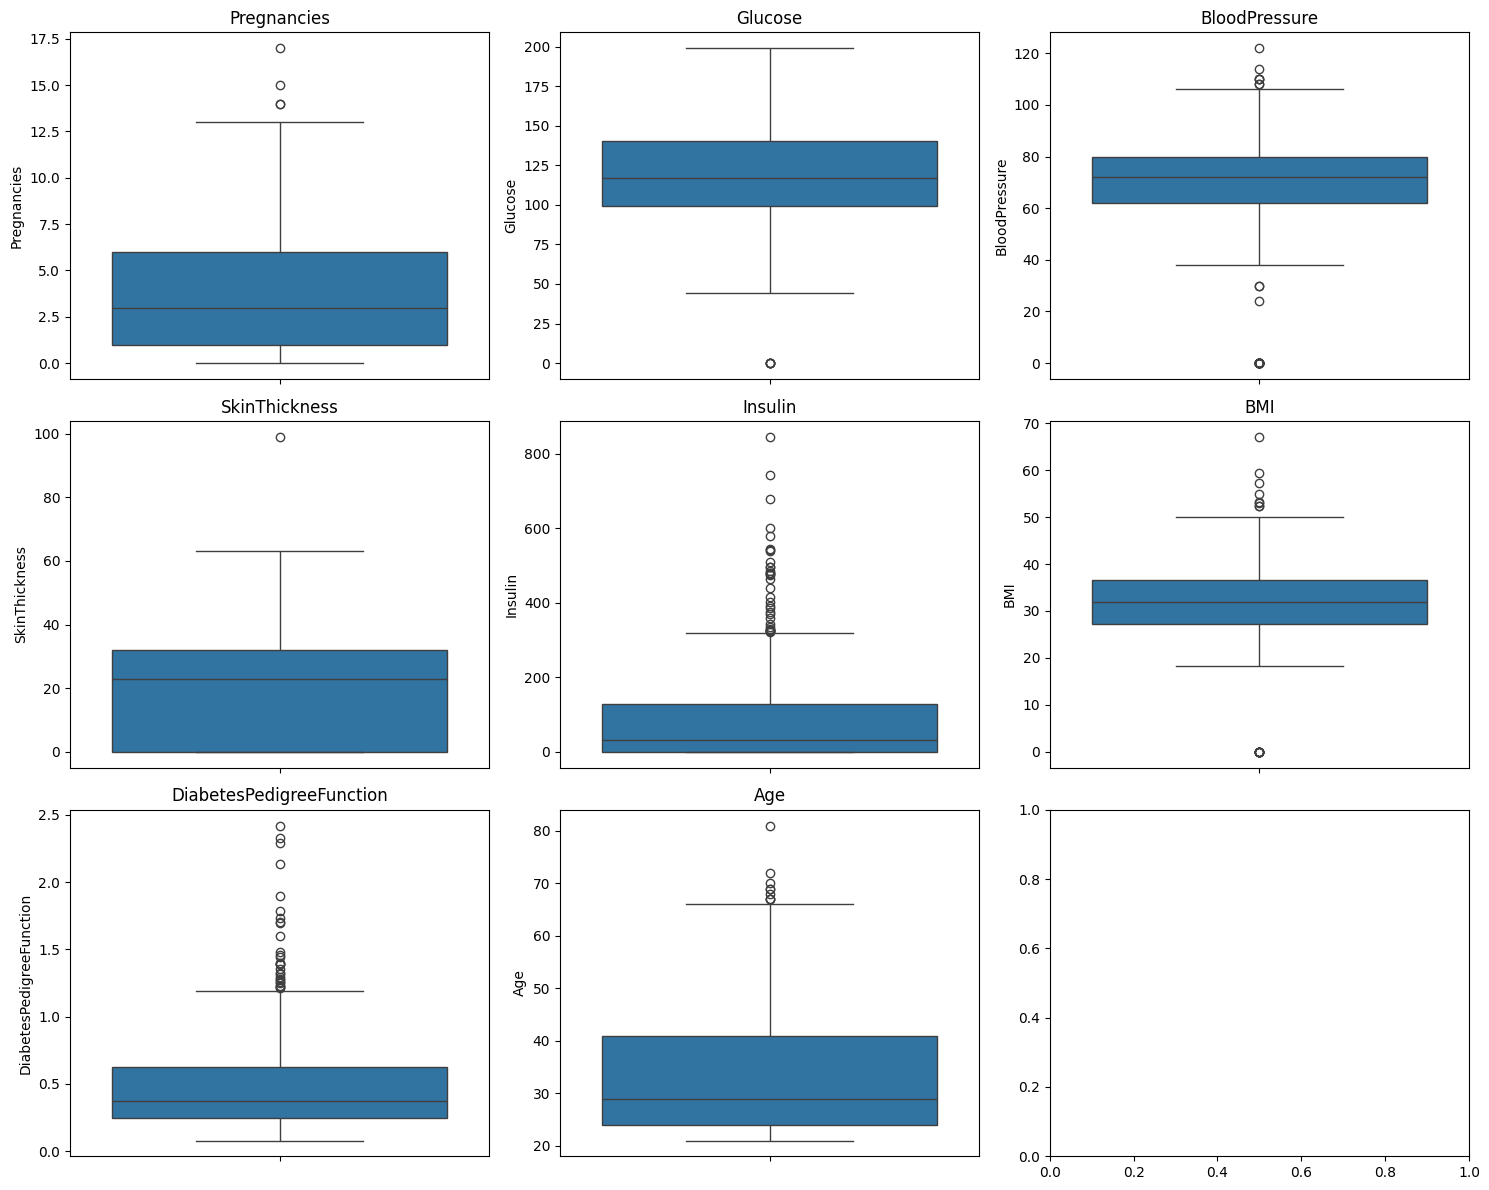

In [10]:
# Cek outlier dengan boxplot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for idx, col in enumerate(df.columns[:-1]):
    sns.boxplot(data=df, y=col, ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Tahapan yang dilakukan:
1. Menangani nilai 0 yang seharusnya NaN (Glucose, BloodPressure, SkinThickness, Insulin, BMI)
2. Mengisi missing values dengan median
3. Split data train/test
4. Standarisasi fitur numerik

In [11]:
# Kolom yang tidak mungkin bernilai 0
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_not_allowed:
    df[col] = df[col].replace(0, np.nan)

print('Jumlah NaN setelah replace 0:')
print(df[zero_not_allowed].isnull().sum())

Jumlah NaN setelah replace 0:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [12]:
# Isi NaN dengan median
for col in zero_not_allowed:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print('Cek missing values setelah handling:')
print(df.isnull().sum())

Cek missing values setelah handling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [13]:
# Split fitur dan target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train distribution: \n{y_train.value_counts()}')
print(f'y_test distribution: \n{y_test.value_counts()}')

X_train: (614, 8)
X_test: (154, 8)
y_train distribution: 
Outcome
0    400
1    214
Name: count, dtype: int64
y_test distribution: 
Outcome
0    100
1     54
Name: count, dtype: int64


In [14]:
# Standarisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print('Data setelah standarisasi:')
print(f'X_train mean: {X_train_scaled.mean().round(2)}')
print(f'X_train std: {X_train_scaled.std().round(2)}')

Data setelah standarisasi:
X_train mean: Pregnancies                -0.0
Glucose                    -0.0
BloodPressure               0.0
SkinThickness              -0.0
Insulin                    -0.0
BMI                        -0.0
DiabetesPedigreeFunction   -0.0
Age                        -0.0
dtype: float64
X_train std: Pregnancies                 1.0
Glucose                     1.0
BloodPressure               1.0
SkinThickness               1.0
Insulin                     1.0
BMI                         1.0
DiabetesPedigreeFunction    1.0
Age                         1.0
dtype: float64


In [16]:
# Simpan hasil preprocessing
train_df = X_train_scaled.copy()
train_df['Outcome'] = y_train.values

test_df = X_test_scaled.copy()
test_df['Outcome'] = y_test.values

train_df.to_csv('diabetes_preprocessing/train.csv', index=False)
test_df.to_csv('diabetes_preprocessing/test.csv', index=False)

print('Dataset preprocessing berhasil disimpan!')
print(f'Train: {train_df.shape}')
print(f'Test: {test_df.shape}')

Dataset preprocessing berhasil disimpan!
Train: (614, 9)
Test: (154, 9)


In [17]:
!rm -rf sample_data

In [18]:
!zip -r output.zip diabetes_preprocessing/ diabetes_raw/

  adding: diabetes_preprocessing/ (stored 0%)
  adding: diabetes_preprocessing/test.csv (deflated 72%)
  adding: diabetes_preprocessing/train.csv (deflated 78%)
  adding: diabetes_raw/ (stored 0%)
  adding: diabetes_raw/diabetes.csv (deflated 63%)
